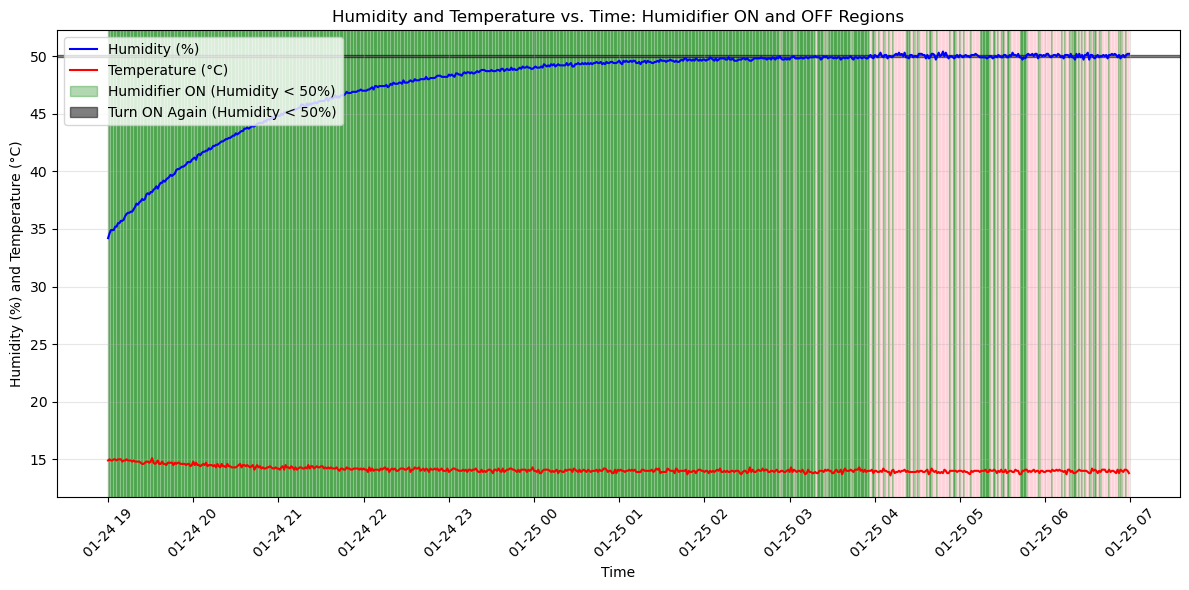

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates
from datetime import datetime

df = pd.read_csv('temperature_humidity_data3.csv')

df['Time'] = pd.to_datetime(df['Time'])

df = df.sort_values('Time')

df['humidifier_state'] = 0

upper_threshold = 50  

current_state = 1 if df['Humidity (%)'].iloc[0] < upper_threshold else 0

for i in range(len(df)):
    if current_state == 1: 
        if df['Humidity (%)'].iloc[i] >= upper_threshold:
            current_state = 0 
    else:  
        if df['Humidity (%)'].iloc[i] < upper_threshold:
            current_state = 1 
    df.loc[df.index[i], 'humidifier_state'] = current_state

plt.figure(figsize=(12, 6))

plt.plot(df['Time'], df['Humidity (%)'], 'b-', label='Humidity (%)')
plt.plot(df['Time'], df['Temperature (°C)'], 'r-', label='Temperature (°C)')

for i in range(len(df)-1):
    if df['humidifier_state'].iloc[i] == 1:
        plt.axvspan(df['Time'].iloc[i], df['Time'].iloc[i+1], 
                    alpha=0.3, color='green', label='_' if i > 0 else 'Humidifier ON (Humidity < 50%)')
    else:
        plt.axvspan(df['Time'].iloc[i], df['Time'].iloc[i+1], 
                    alpha=0.3, color='pink', label='_' if i > 0 else 'Humidifier OFF (Humidity >= 50%)')

plt.axhspan(upper_threshold-0.1, upper_threshold+0.1, color='black', alpha=0.5, 
           label='Turn ON Again (Humidity < 50%)')

# labels and plot

plt.xlabel('Time')
plt.ylabel('Humidity (%) and Temperature (°C)')
plt.title('Humidity and Temperature vs. Time: Humidifier ON and OFF Regions')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H'))
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=1))  
plt.xticks(rotation=45)

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc='upper left')

plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.savefig('humidity_temperature_chart_updated.png', dpi=300)
plt.show()


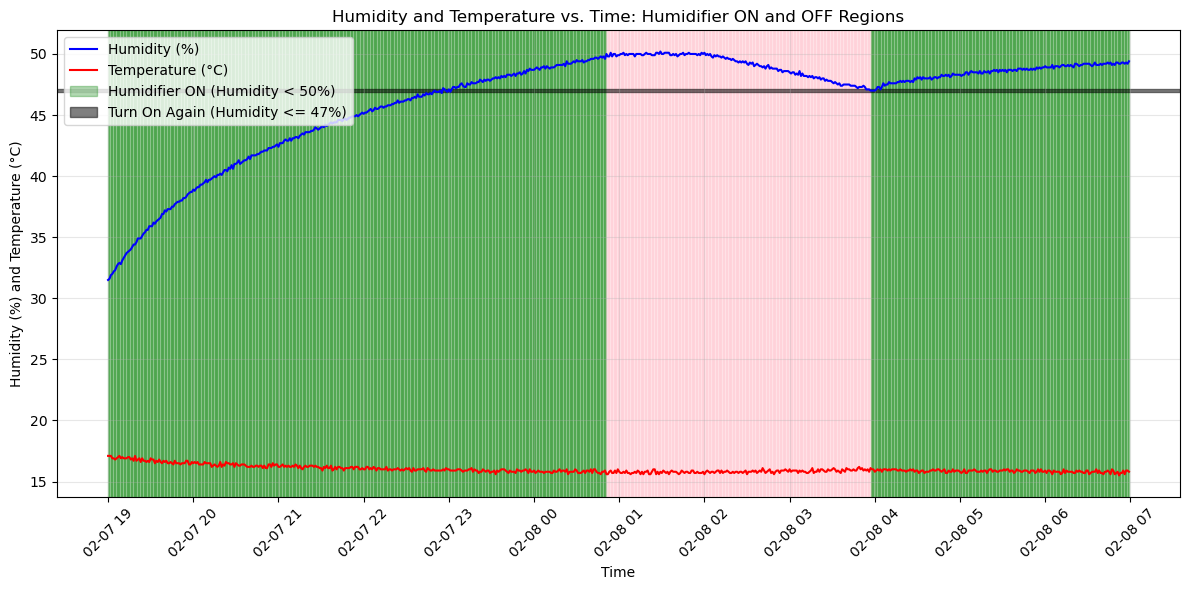

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates
from datetime import datetime

df = pd.read_csv('temperature_humidity_data1.csv')

df['Time'] = pd.to_datetime(df['Time'])

df = df.sort_values('Time')

df['humidifier_state'] = 0

upper_threshold = 50 #off at this level
lower_threshold = 47 #on at this level

current_state = 1 if df['Humidity (%)'].iloc[0] < upper_threshold else 0


for i in range(len(df)):
    if current_state == 1:  
        if df['Humidity (%)'].iloc[i] >= upper_threshold:
            current_state = 0  
    else:  
        if df['Humidity (%)'].iloc[i] <= lower_threshold:
            current_state = 1 
    df.loc[df.index[i], 'humidifier_state'] = current_state


plt.figure(figsize=(12, 6))
plt.plot(df['Time'], df['Humidity (%)'], 'b-', label='Humidity (%)')
plt.plot(df['Time'], df['Temperature (°C)'], 'r-', label='Temperature (°C)')

for i in range(len(df)-1):
    if df['humidifier_state'].iloc[i] == 1:
        plt.axvspan(df['Time'].iloc[i], df['Time'].iloc[i+1], 
                    alpha=0.3, color='green', label='_' if i > 0 else 'Humidifier ON (Humidity < 50%)')
    else:
        plt.axvspan(df['Time'].iloc[i], df['Time'].iloc[i+1], 
                    alpha=0.3, color='pink', label='_' if i > 0 else 'Humidifier OFF (Humidity >= 50%)')

plt.axhspan(lower_threshold-0.1, lower_threshold+0.1, color='black', alpha=0.5, 
           label='Turn On Again (Humidity <= 47%)')

# labels and plots
plt.xlabel('Time')
plt.ylabel('Humidity (%) and Temperature (°C)')
plt.title('Humidity and Temperature vs. Time: Humidifier ON and OFF Regions')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H'))
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=1))  # Changed from 4 to 1 hour
plt.xticks(rotation=45)

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc='upper left')
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.savefig('humidity_temperature_chart.png', dpi=300)
plt.show()

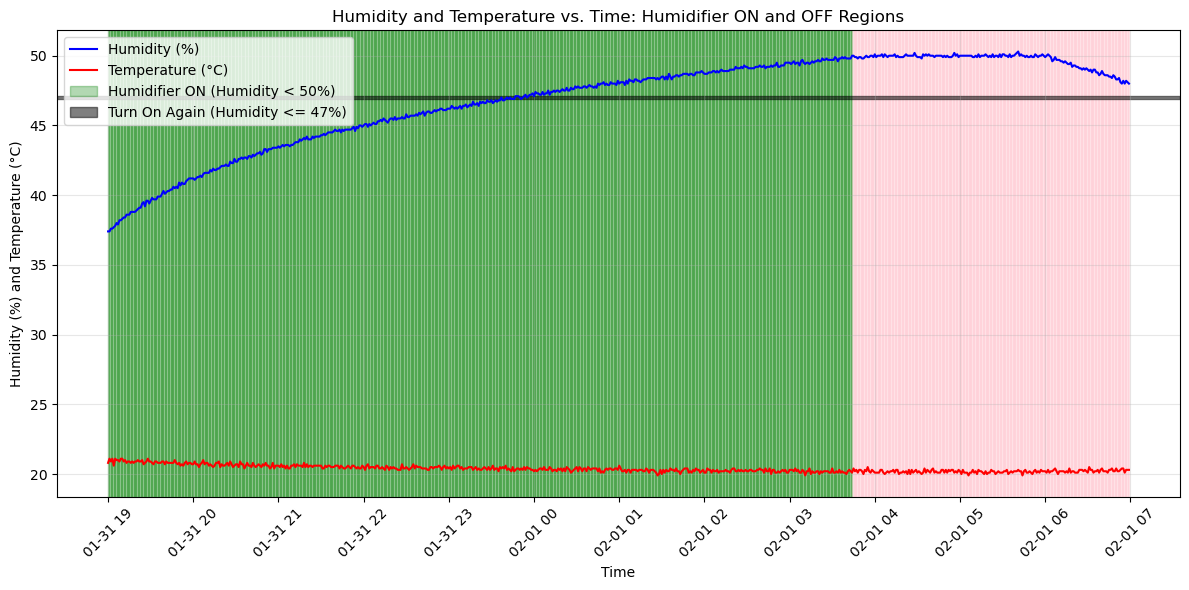

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates
from datetime import datetime

df = pd.read_csv('temperature_humidity_data2.csv')

df['Time'] = pd.to_datetime(df['Time'])

df = df.sort_values('Time')

df['humidifier_state'] = 0

upper_threshold = 50  
lower_threshold = 47  

current_state = 1 if df['Humidity (%)'].iloc[0] < upper_threshold else 0

for i in range(len(df)):
    if current_state == 1: 
        if df['Humidity (%)'].iloc[i] >= upper_threshold:
            current_state = 0  
    else:  
        if df['Humidity (%)'].iloc[i] <= lower_threshold:
            current_state = 1  
            
    df.loc[df.index[i], 'humidifier_state'] = current_state

plt.figure(figsize=(12, 6))

plt.plot(df['Time'], df['Humidity (%)'], 'b-', label='Humidity (%)')
plt.plot(df['Time'], df['Temperature (°C)'], 'r-', label='Temperature (°C)')

for i in range(len(df)-1):
    if df['humidifier_state'].iloc[i] == 1:
        plt.axvspan(df['Time'].iloc[i], df['Time'].iloc[i+1], 
                    alpha=0.3, color='green', label='_' if i > 0 else 'Humidifier ON (Humidity < 50%)')
    else:
        plt.axvspan(df['Time'].iloc[i], df['Time'].iloc[i+1], 
                    alpha=0.3, color='pink', label='_' if i > 0 else 'Humidifier OFF (Humidity >= 50%)')

plt.axhspan(lower_threshold-0.1, lower_threshold+0.1, color='black', alpha=0.5, 
           label='Turn On Again (Humidity <= 47%)')

#labels and plot

plt.xlabel('Time')
plt.ylabel('Humidity (%) and Temperature (°C)')
plt.title('Humidity and Temperature vs. Time: Humidifier ON and OFF Regions')


plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H'))
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=1))  
plt.xticks(rotation=45)

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc='upper left')

plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.savefig('humidity_temperature_chart.png', dpi=300)
plt.show()

In [ ]:
LSTM Model

In [7]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, RepeatVector, TimeDistributed, Dense
from sklearn.model_selection import train_test_split

# 1. Load & merge CSVs
files = [
    'temperature_humidity_data1.csv',
    'temperature_humidity_data2.csv',
    'temperature_humidity_data3.csv'
]
dfs = [pd.read_csv(f, parse_dates=['timestamp']) for f in files]
df = pd.concat(dfs).sort_values('timestamp').reset_index(drop=True)

# 2. Resample hourly & interpolate missing values
df = (
    df.set_index('timestamp')
      .resample('H')
      .mean()
      .interpolate()
)

# 3. Extract humidity series
series = df['humidity'].values

# 4. Define sequence lengths
input_len  = 24   # past 24 hours
output_len = 13   # next-day 7pm→7am (inclusive)

# 5. Build sliding windows where prediction window starts at 19:00
X, y = [], []
for i in range(len(series) - input_len - output_len + 1):
    end_input = i + input_len
    if df.index[end_input].hour == 19:
        X.append(series[i:end_input])
        y.append(series[end_input : end_input + output_len])

X = np.array(X).reshape(-1, input_len, 1)
y = np.array(y).reshape(-1, output_len, 1)

# 6. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# 7. Scale data to [0,1]
x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

X_train_flat = X_train.reshape(-1, 1)
y_train_flat = y_train.reshape(-1, 1)

x_scaler.fit(X_train_flat)
y_scaler.fit(y_train_flat)

X_train = x_scaler.transform(X_train_flat).reshape(X_train.shape)
X_test  = x_scaler.transform(X_test.reshape(-1,1)).reshape(X_test.shape)
y_train = y_scaler.transform(y_train_flat).reshape(y_train.shape)
y_test  = y_scaler.transform(y_test.reshape(-1,1)).reshape(y_test.shape)

# 8. Build Seq2Seq LSTM model
model = Sequential([
    LSTM(50, activation='relu', input_shape=(input_len, 1)),
    RepeatVector(output_len),
    LSTM(50, activation='relu', return_sequences=True),
    TimeDistributed(Dense(1))
])
model.compile(optimizer='adam', loss='mse')
model.summary()

# 9. Train
model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=16,
    validation_data=(X_test, y_test)
)

# 10. Predict next humidity curve
last_seq     = series[-input_len:]
last_scaled  = x_scaler.transform(last_seq.reshape(-1,1)).reshape(1, input_len, 1)
pred_scaled  = model.predict(last_scaled)
pred_humidity = y_scaler.inverse_transform(pred_scaled.reshape(-1,1)).reshape(output_len)

print("Predicted humidity from 7 pm to 7 am:", pred_humidity)


ImportError: Traceback (most recent call last):
  File "C:\Users\maan3\anaconda3\Lib\site-packages\tensorflow\python\pywrap_tensorflow.py", line 73, in <module>
    from tensorflow.python._pywrap_tensorflow_internal import *
ImportError: DLL load failed while importing _pywrap_tensorflow_internal: A dynamic link library (DLL) initialization routine failed.


Failed to load the native TensorFlow runtime.
See https://www.tensorflow.org/install/errors for some common causes and solutions.
If you need help, create an issue at https://github.com/tensorflow/tensorflow/issues and include the entire stack trace above this error message.

In [9]:
conda create -n tf39 python=3.9
conda activate tf39
conda install -c conda-forge tensorflow jupyter
jupyter notebook

SyntaxError: invalid syntax (2348463814.py, line 1)

In [11]:
pip uninstall tensorflow
pip install tensorflow-cpu

SyntaxError: invalid syntax (1834094386.py, line 1)